In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
root_path = Path().resolve().parent.parent

sys.path.append(str(root_path))

from utils.eda import summary_stats, missing_report, outlier_report, class_balance, correlation_matrix
from utils.visualization import plot_distributions, plot_boxplot, plot_class_balance

In [18]:
df = pd.read_csv(root_path / "video games sales" / 'data' / 'vgsales.csv')
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [3]:
summary_stats(df)

SHAPE        : 16598 rows × 11 columns

── DTYPES ──
                dtype  nunique      sample
Rank            int64    16598           1
Name           object    11493  Wii Sports
Platform       object       31         Wii
Year          float64       39      2006.0
Genre          object       12      Sports
Publisher      object      578    Nintendo
NA_Sales      float64      409       41.49
EU_Sales      float64      305       29.02
JP_Sales      float64      244        3.77
Other_Sales   float64      157        8.46
Global_Sales  float64      623       82.74


In [4]:
missing_report(df)

MISSING VALUE REPORT  (total kolom: 11)
           missing_count  missing_pct    dtype
Year                 271         1.63  float64
Publisher             58         0.35   object


In [5]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


In [6]:
df['Genre'].value_counts()

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

In [7]:
fitur_numeric = df.select_dtypes(include='number').columns.tolist()
fitur_category = df.select_dtypes(include='object').columns.tolist()

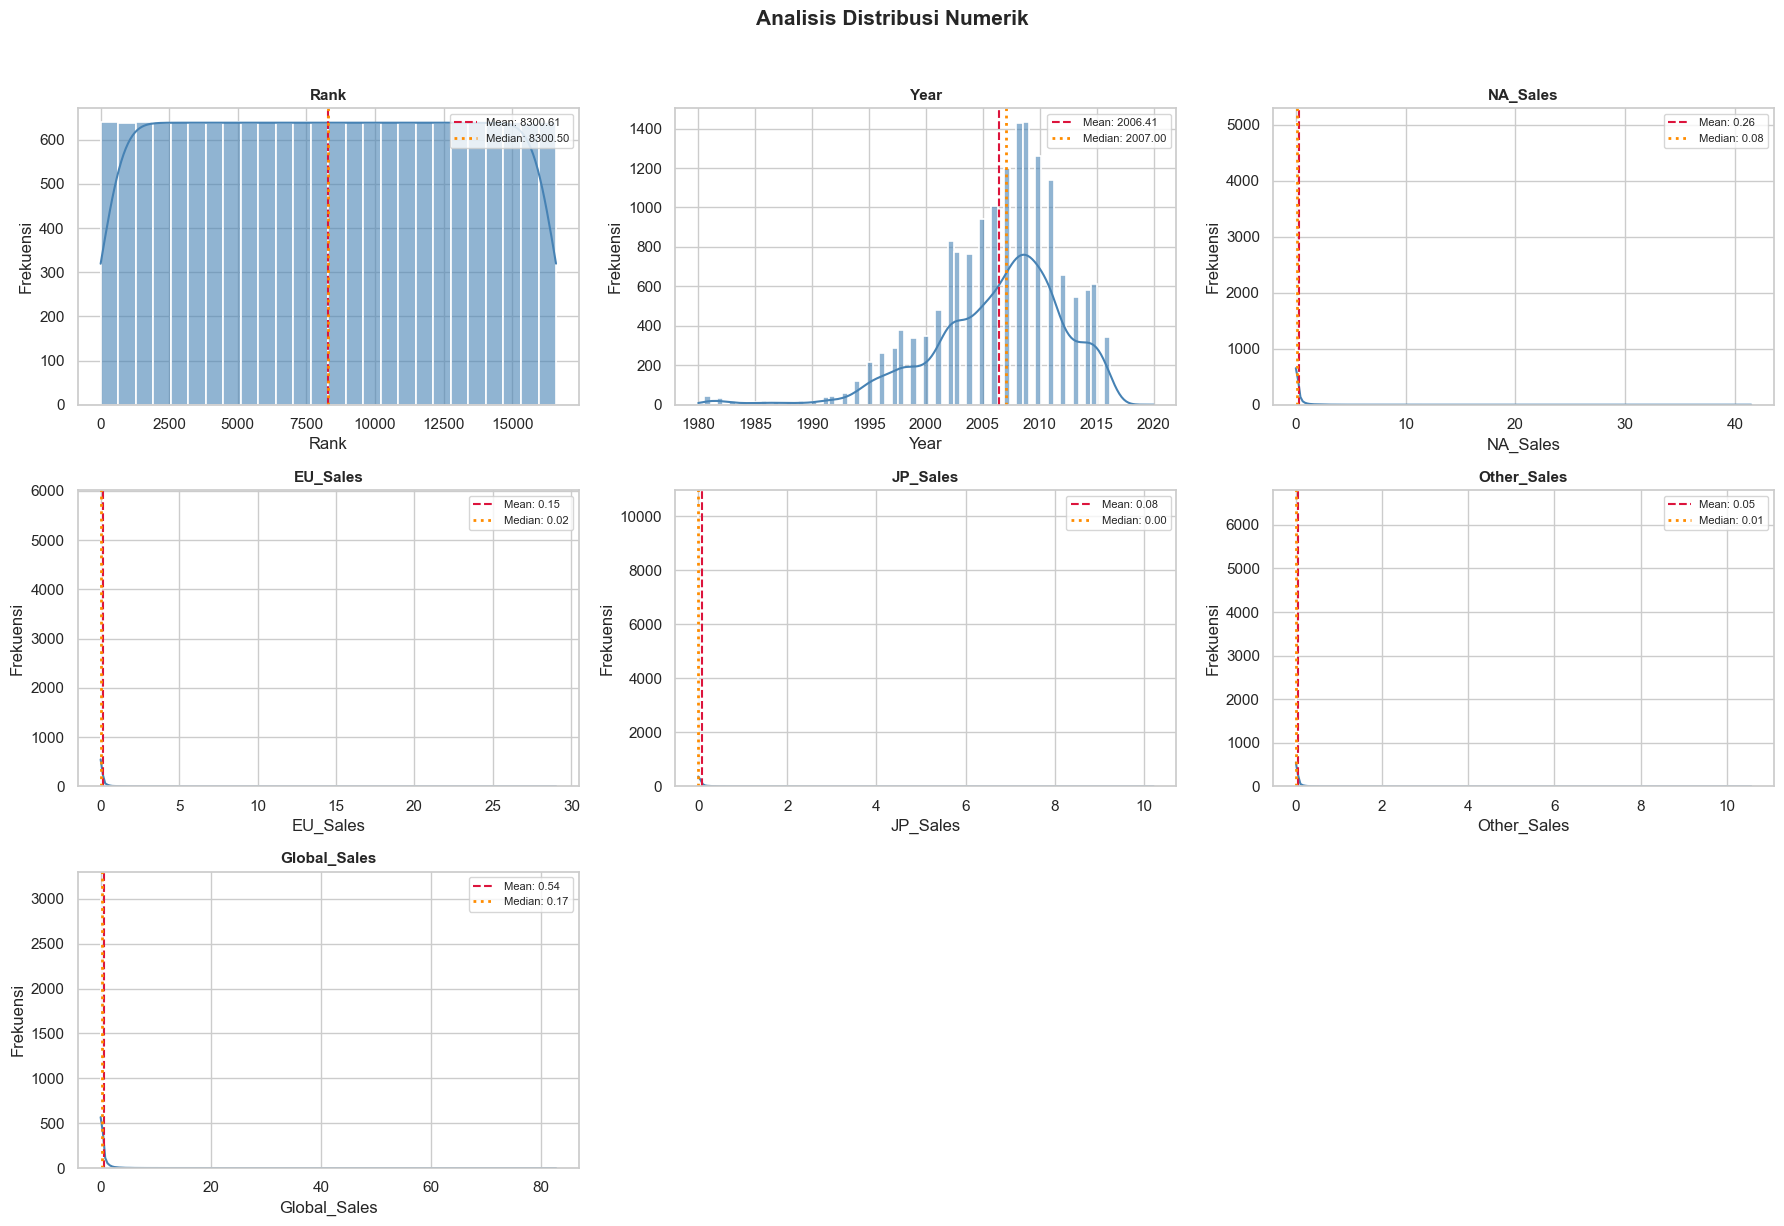

In [8]:
plot_distributions(df, fitur_numeric)

In [9]:
outlier_report(df)

OUTLIER REPORT  (method=iqr)
      column  n_outliers  pct_outliers  has_outlier  lower_bound  upper_bound
    JP_Sales        2425         14.61         True       -0.060        0.100
    EU_Sales        2081         12.54         True       -0.165        0.275
Global_Sales        1893         11.40         True       -0.555        1.085
    NA_Sales        1681         10.13         True       -0.360        0.600
 Other_Sales        1665         10.03         True       -0.060        0.100
        Year         305          1.87         True     1992.500     2020.500

Kolom dengan outlier: 6 / 7


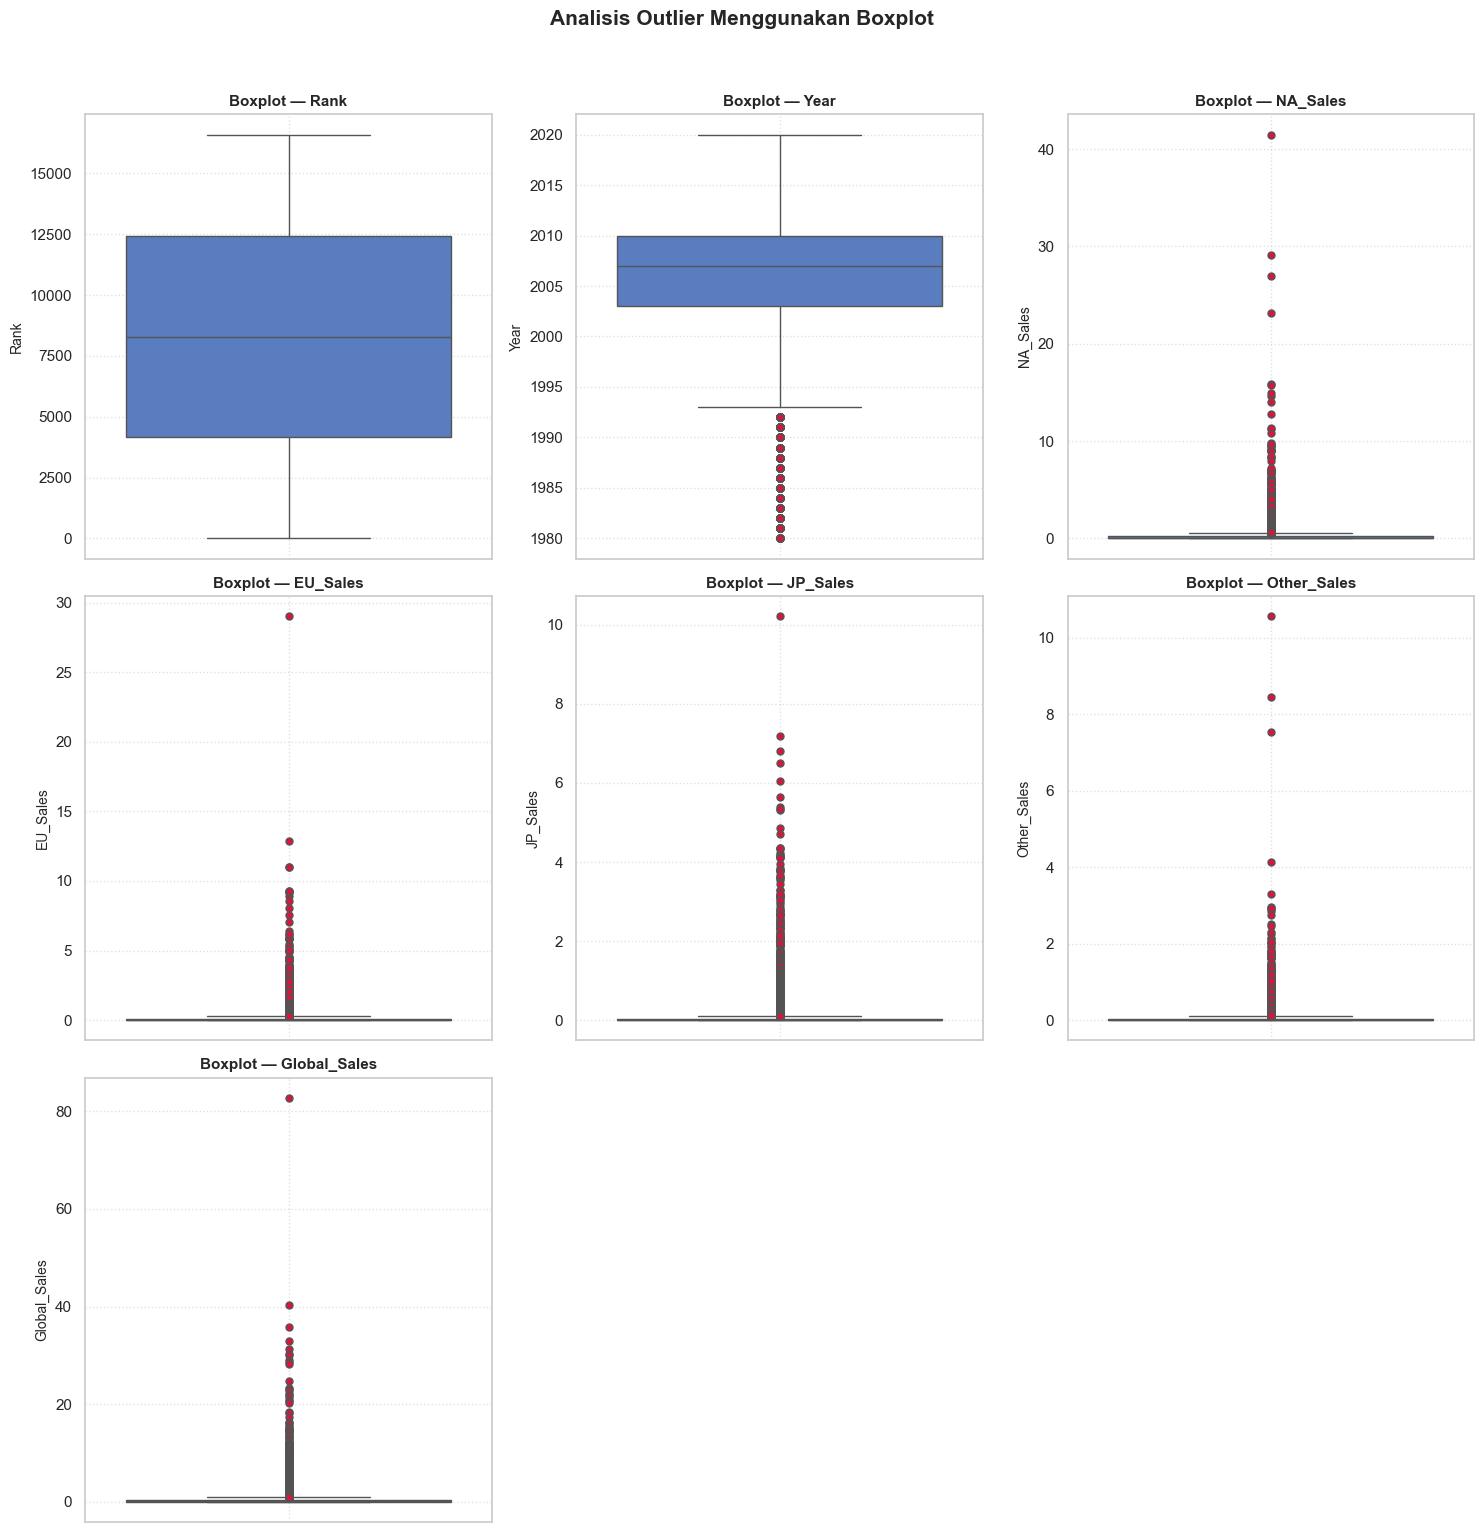

In [10]:
plot_boxplot(df, fitur_numeric)

Text(0.5, 1.0, 'Genre Game Paling Banyak Rilis')

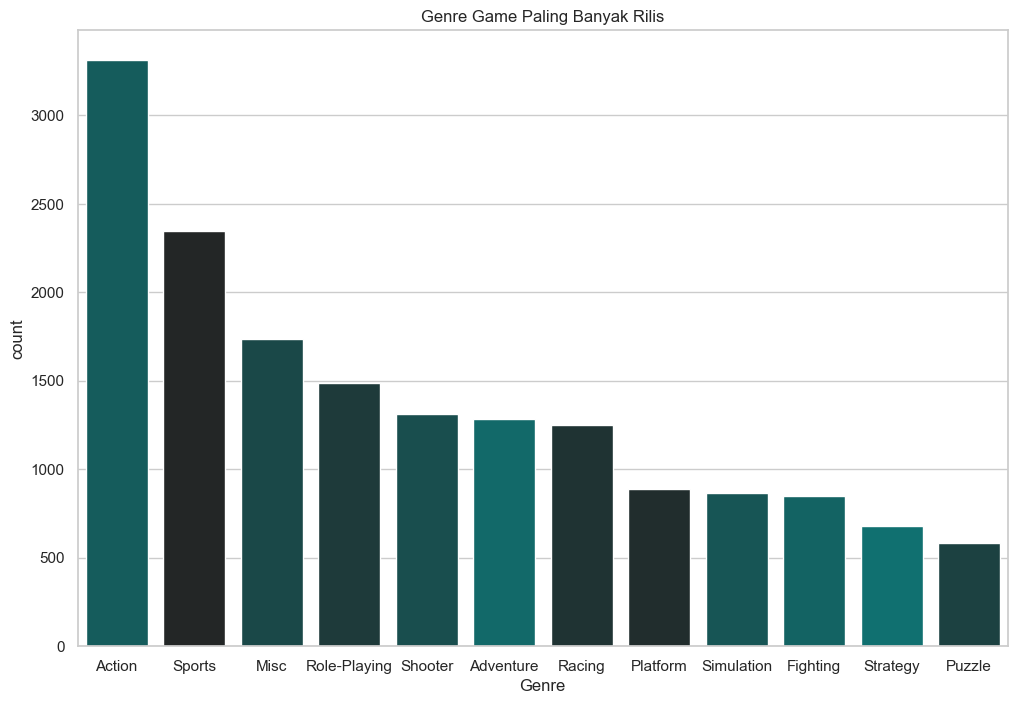

In [11]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x="Genre", order=df['Genre'].value_counts().index,
             palette='dark:teal',
             hue='Genre')
plt.title("Genre Game Paling Banyak Rilis")

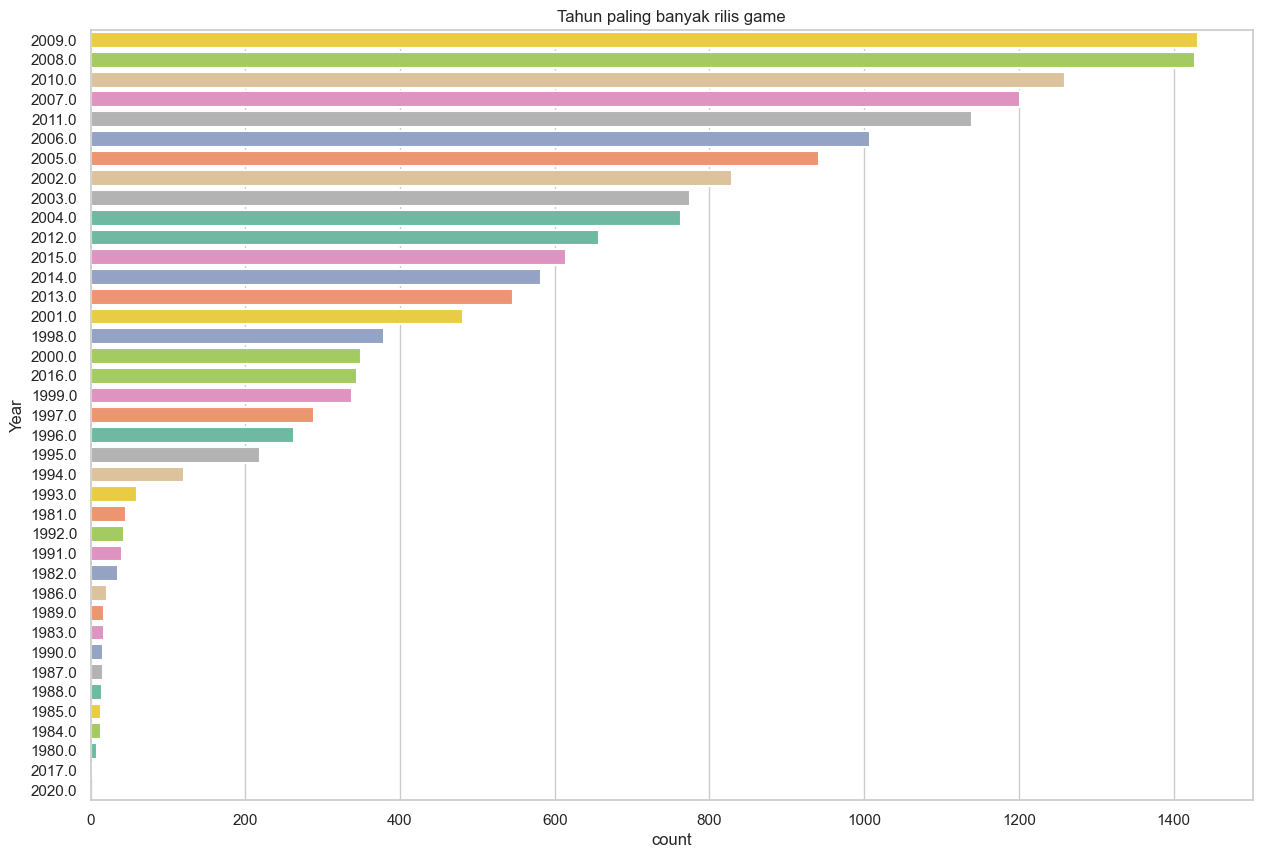

In [12]:
plt.figure(figsize=(15, 10))
sns.countplot(df, y='Year', hue='Year', order=df['Year'].value_counts().index,
              palette='Set2', legend=False,
              edgecolor='white',     
              linewidth=1.5,         
              saturation=0.8,       
              width=0.8)              
plt.title("Tahun paling banyak rilis game")
plt.show()

C:\Users\aril\AppData\Local\Temp\ipykernel_1408\2648828146.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, y="Publisher", order = top_publisher,


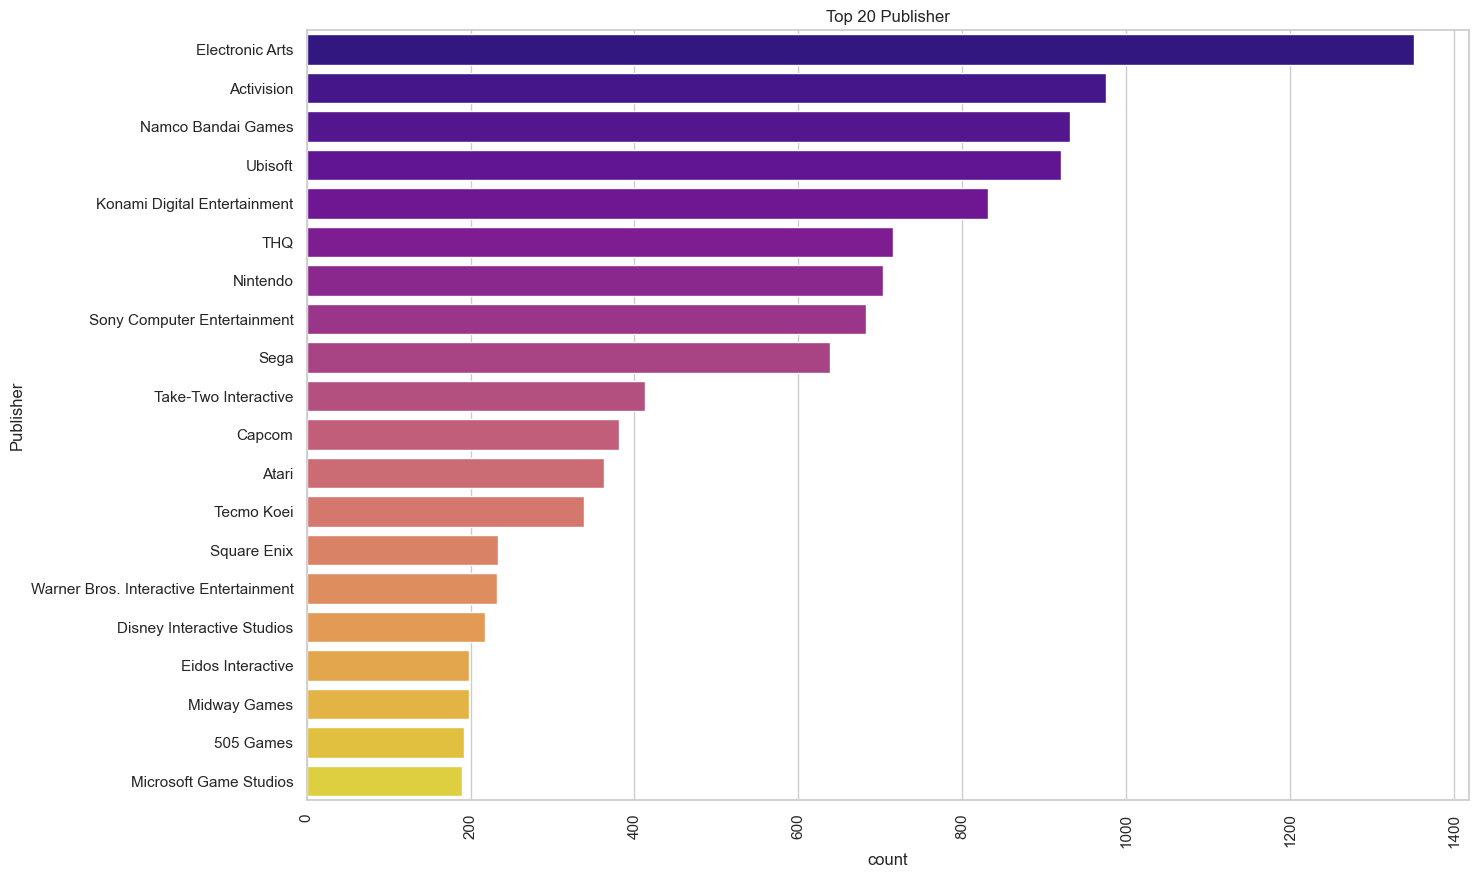

In [13]:
top_publisher = df.groupby(by=['Publisher'])['Year'].count().sort_values(ascending=False).head(20).index

plt.figure(figsize=(15, 10))
sns.countplot(df, y="Publisher", order = top_publisher,
             palette='plasma')
plt.xticks(rotation=90)
plt.title("Top 20 Publisher")
plt.show()

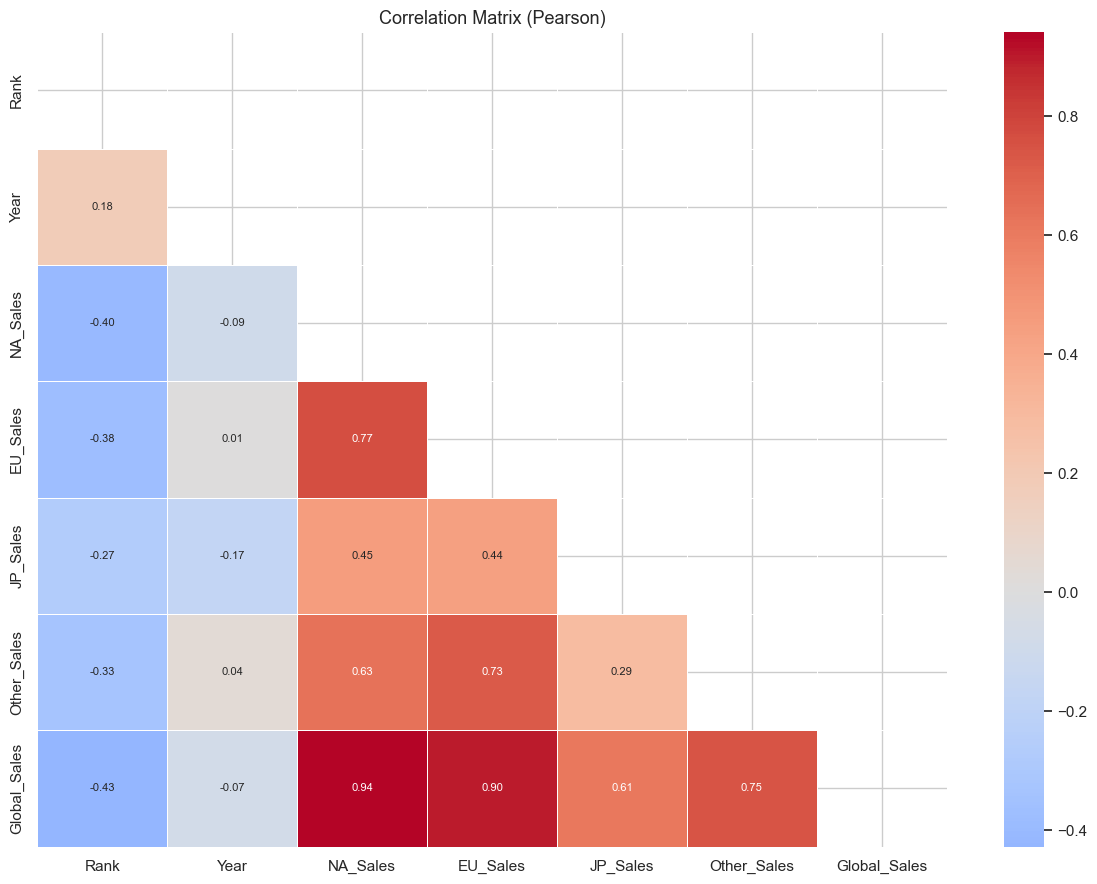

In [14]:
correlation_matrix(df)